<div style="text-align:center; padding:18px; border:2px solid #4f8cff; border-radius:12px;">

# Basic Math for AI-ML Practice

### Assignment #2 — Sec 02

**ชื่อ-นามสกุล:** `ณัฐพล ยิ้มน้อย`

**รหัสนักศึกษา:** `6710110132`

</div>

---
# Library Importing

นำเข้า library ที่ใช้ทั้งหมด พร้อมแสดง **version** ของแต่ละตัว

In [30]:
#Library Importing
import importlib
import importlib.util
import platform
import subprocess
import sys

# ติดตั้ง package ที่ยังไม่มีอัตโนมัติ (ชื่อที่ใช้ import, ชื่อบน PyPI)
REQUIRED_PACKAGES = [
    ("numpy", "numpy"),
    ("sympy", "sympy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
]

missing = [pypi for module, pypi in REQUIRED_PACKAGES if importlib.util.find_spec(module) is None]
if missing:
    print(f"Installing missing packages: {', '.join(missing)} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    importlib.invalidate_caches()
    print("Install complete.\n")

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ตั้งค่าการแสดงผลให้อ่านง่าย
np.set_printoptions(precision=4, suppress=True)   # ทศนิยม 4 ตำแหน่ง ไม่ใช้ scientific notation
pd.set_option("display.precision", 4)
%matplotlib inline

# ตั้ง seed เพื่อให้การสุ่มทำซ้ำได้ (reproducible)
SEED = 42
rng = np.random.default_rng(SEED)

print("Environment / Library versions")
print("=" * 46)
print(f"{'Python':<14}: {platform.python_version()}")
print(f"{'NumPy':<14}: {np.__version__}")
print(f"{'SymPy':<14}: {sp.__version__}")
print(f"{'pandas':<14}: {pd.__version__}")
print(f"{'Matplotlib':<14}: {matplotlib.__version__}")
print("=" * 46)
print(f"random seed    : {SEED}")

Environment / Library versions
Python        : 3.11.9
NumPy         : 2.4.4
SymPy         : 1.14.0
pandas        : 3.0.2
Matplotlib    : 3.11.1
random seed    : 42


---
# Section 1 - Vector

**Vector** คือลำดับของตัวเลขที่มีทั้ง *ขนาด (magnitude)* และ *ทิศทาง (direction)*
ในงาน AI/ML เราใช้ vector แทน ข้อมูล 1 รายการ (sample) หรือ ชุดพารามิเตอร์ (weights)
ในหัวข้อนี้ใช้ vector 3 มิติ ตามโจทย์:

$$
\mathbf{a} = \begin{bmatrix} a_1 \\ a_2 \\ a_3 \end{bmatrix} \in \mathbb{R}^3
\qquad
\mathbf{b} = \begin{bmatrix} b_1 \\ b_2 \\ b_3 \end{bmatrix} \in \mathbb{R}^3
$$

In [31]:
# ===== สุ่ม vector 3 มิติ 2 ตัว =====
a = rng.integers(-9, 10, size=3).astype(float)
b = rng.integers(-9, 10, size=3).astype(float)

print("vector a =", a, "  shape =", a.shape)
print("vector b =", b, "  shape =", b.shape)

vector a = [-8.  5.  3.]   shape = (3,)
vector b = [-1. -1.  7.]   shape = (3,)


## 1.1a Vector Addition / Subtraction

บวก–ลบแบบ **ทีละตำแหน่ง (element-wise)** ทั้งสอง vector ต้องมีมิติเท่ากัน

$$
\mathbf{a} + \mathbf{b} =
\begin{bmatrix} a_1 + b_1 \\ a_2 + b_2 \\ a_3 + b_3 \end{bmatrix}
\qquad\qquad1
\mathbf{a} - \mathbf{b} =
\begin{bmatrix} a_1 - b_1 \\ a_2 - b_2 \\ a_3 - b_3 \end{bmatrix}
$$

**ความหมายเชิงเรขาคณิต:** การบวกคือการนำลูกศรมาต่อหางกัน (tip-to-tail)

In [32]:
add = a + b
sub = a - b

print(f"a          = {a}")
print(f"b          = {b}")
print("-" * 34)
print(f"a + b      = {add}")
print(f"a - b      = {sub}")

# ตรวจสอบทีละตำแหน่งด้วยมือ (manual check)
manual_add = np.array([a[i] + b[i] for i in range(3)])
manual_sub = np.array([a[i] - b[i] for i in range(3)])
print("-" * 34)
print("ตรวจสอบ manual vs numpy :",
      np.allclose(manual_add, add) and np.allclose(manual_sub, sub))

a          = [-8.  5.  3.]
b          = [-1. -1.  7.]
----------------------------------
a + b      = [-9.  4. 10.]
a - b      = [-7.  6. -4.]
----------------------------------
ตรวจสอบ manual vs numpy : True


## 1.2b Vector Scaling (Scalar Multiplication)

การคูณ vector ด้วย **scalar** $k$ คือการ *ยืด/หด* ความยาว โดย **ทิศทางคงเดิม**
(ถ้า $k < 0$ ทิศทางจะกลับด้าน)

$$
k\mathbf{a} = \begin{bmatrix} k\,a_1 \\ k\,a_2 \\ k\,a_3 \end{bmatrix}
\qquad\text{และ}\qquad
\|k\mathbf{a}\| = |k| \cdot \|\mathbf{a}\|
$$

ใน ML: การอัปเดตน้ำหนักด้วย learning rate $\theta \leftarrow \theta - \alpha \nabla L$ ก็คือการ scale vector gradient นั่นเอง

In [33]:
k1, k2 = 3.0, -0.5

print(f"a            = {a}")
print(f"{k1} * a       = {k1 * a}")
print(f"{k2} * a      = {k2 * a}")
print("-" * 46)

# พิสูจน์สมบัติ ||k*a|| = |k| * ||a||
lhs = np.linalg.norm(k1 * a)
rhs = abs(k1) * np.linalg.norm(a)
print(f"||{k1}a||      = {lhs:.4f}")
print(f"|{k1}| * ||a|| = {rhs:.4f}")
print("สมบัติเป็นจริง :", np.isclose(lhs, rhs))

a            = [-8.  5.  3.]
3.0 * a       = [-24.  15.   9.]
-0.5 * a      = [ 4.  -2.5 -1.5]
----------------------------------------------
||3.0a||      = 29.6985
|3.0| * ||a|| = 29.6985
สมบัติเป็นจริง : True


## 1.3c Dot Product (ผลคูณจุด)

$$
\mathbf{a} \cdot \mathbf{b} \;=\; \sum_{i=1}^{n} a_i b_i \;=\; a_1b_1 + a_2b_2 + a_3b_3
$$

ผลลัพธ์เป็น **scalar** (ตัวเลขตัวเดียว) และยังเขียนในรูปมุมระหว่าง vector ได้ว่า

$$
\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta
$$

**ความสำคัญใน AI/ML:** neuron 1 ตัวคำนวณ $z = \mathbf{w}\cdot\mathbf{x} + b$ ซึ่งก็คือ dot product นั่นเอง

In [34]:
# 3 วิธีที่ให้ผลเท่ากัน
dot_manual = sum(a[i] * b[i] for i in range(3))   # ตามนิยาม
dot_np     = np.dot(a, b)                          # ฟังก์ชัน numpy
dot_at     = a @ b                                 # operator @

print(f"a = {a}")
print(f"b = {b}")
print("-" * 50)
terms = " + ".join([f"({a[i]:.0f})({b[i]:.0f})" for i in range(3)])
print(f"a · b = {terms} = {dot_manual:.4f}")
print("-" * 50)
print(f"np.dot(a, b) = {dot_np:.4f}")
print(f"a @ b        = {dot_at:.4f}")
print("ผลตรงกันทั้ง 3 วิธี :", np.allclose([dot_manual, dot_np], dot_at))

a = [-8.  5.  3.]
b = [-1. -1.  7.]
--------------------------------------------------
a · b = (-8)(-1) + (5)(-1) + (3)(7) = 24.0000
--------------------------------------------------
np.dot(a, b) = 24.0000
a @ b        = 24.0000
ผลตรงกันทั้ง 3 วิธี : True


## 1.4d Magnitude (ความยาว / Norm)

**L2 norm** หรือ Euclidean norm — คือความยาวของลูกศร (ทฤษฎีบทพีทาโกรัสในหลายมิติ)

$$
\|\mathbf{a}\|_2 \;=\; \sqrt{\sum_{i=1}^{n} a_i^2} \;=\; \sqrt{a_1^2 + a_2^2 + a_3^2}
\;=\; \sqrt{\mathbf{a}\cdot\mathbf{a}}
$$

**Unit vector** (เวกเตอร์หนึ่งหน่วย) คือ $\hat{\mathbf{a}} = \dfrac{\mathbf{a}}{\|\mathbf{a}\|}$ ซึ่งมีความยาวเท่ากับ 1

In [35]:
mag_manual = np.sqrt(sum(a[i] ** 2 for i in range(3)))
mag_np     = np.linalg.norm(a)

print(f"a = {a}")
inside = " + ".join([f"({a[i]:.0f})²" for i in range(3)])
print(f"||a|| = sqrt({inside}) = sqrt({sum(a**2):.0f}) = {mag_manual:.4f}")
print(f"np.linalg.norm(a)      = {mag_np:.4f}")
print(f"||b||                  = {np.linalg.norm(b):.4f}")
print("-" * 50)

# unit vector
a_hat = a / np.linalg.norm(a)
print(f"unit vector â = a/||a|| = {a_hat}")
print(f"ความยาวของ â            = {np.linalg.norm(a_hat):.4f}  (ต้องเท่ากับ 1)")

a = [-8.  5.  3.]
||a|| = sqrt((-8)² + (5)² + (3)²) = sqrt(98) = 9.8995
np.linalg.norm(a)      = 9.8995
||b||                  = 7.1414
--------------------------------------------------
unit vector â = a/||a|| = [-0.8081  0.5051  0.303 ]
ความยาวของ â            = 1.0000  (ต้องเท่ากับ 1)


## 1.5e Cosine Similarity

วัด **ความคล้ายเชิงทิศทาง** ของ vector 2 ตัว โดย *ตัดผลของขนาดออก*

$$
\cos\theta = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}
\qquad \cos\theta \in [-1, 1]
$$

| ค่า | ความหมาย |
|-----|----------|
| $+1$ | ทิศทางเดียวกันสนิท |
| $0$ | ตั้งฉากกัน (ไม่เกี่ยวข้องกัน) |
| $-1$ | ทิศทางตรงกันข้าม |

**การใช้งานใน AI/ML:** เปรียบเทียบความคล้ายของ *embedding* ในงานค้นหาเอกสาร, recommendation และ semantic search

In [36]:
def cosine_similarity(u, v):
    """cos(theta) = (u . v) / (||u|| * ||v||)"""
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))

cos_ab = cosine_similarity(a, b)
theta  = np.degrees(np.arccos(np.clip(cos_ab, -1, 1)))

print(f"a = {a}")
print(f"b = {b}")
print("-" * 56)
print(f"a · b      = {np.dot(a, b):.4f}")
print(f"||a||·||b|| = {np.linalg.norm(a) * np.linalg.norm(b):.4f}")
print(f"cosine similarity(a, b) = {cos_ab:.4f}")
print(f"มุมระหว่าง vector       = {theta:.2f} องศา")
print("-" * 56)

# กรณีพิเศษ เพื่อยืนยันช่วงค่า [-1, 1]
same     = cosine_similarity(a, 2 * a)          # ทิศเดียวกัน (scale ต่างกัน)
opposite = cosine_similarity(a, -a)             # ตรงข้าม
orthog   = cosine_similarity(np.array([1., 0., 0.]), np.array([0., 1., 0.]))
print(f"cos(a, 2a)  = {same:+.4f}   -> ทิศเดียวกัน (ขนาดไม่มีผล)")
print(f"cos(a, -a)  = {opposite:+.4f}   -> ตรงกันข้าม")
print(f"cos(x̂, ŷ)   = {orthog:+.4f}   -> ตั้งฉาก")

a = [-8.  5.  3.]
b = [-1. -1.  7.]
--------------------------------------------------------
a · b      = 24.0000
||a||·||b|| = 70.6965
cosine similarity(a, b) = 0.3395
มุมระหว่าง vector       = 70.15 องศา
--------------------------------------------------------
cos(a, 2a)  = +1.0000   -> ทิศเดียวกัน (ขนาดไม่มีผล)
cos(a, -a)  = -1.0000   -> ตรงกันข้าม
cos(x̂, ŷ)   = +0.0000   -> ตั้งฉาก


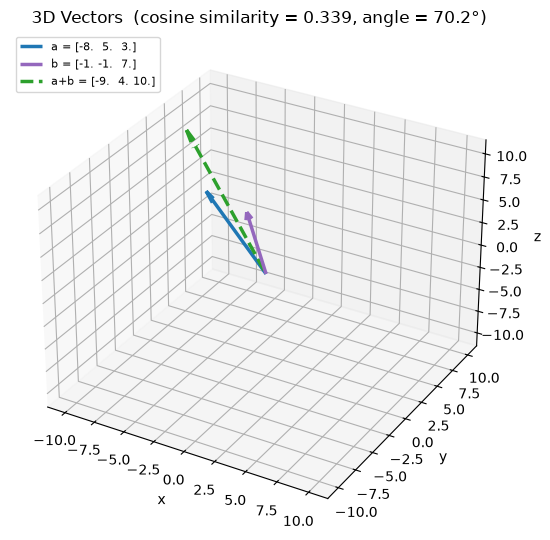

In [37]:
# ===== วาดภาพ vector a, b ในปริภูมิ 3 มิติ =====
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

origin = np.zeros(3)
ax.quiver(*origin, *a, color="tab:blue",   arrow_length_ratio=0.12, linewidth=2.5, label=f"a = {a}")
ax.quiver(*origin, *b, color="tab:purple", arrow_length_ratio=0.12, linewidth=2.5, label=f"b = {b}")
ax.quiver(*origin, *(a + b), color="tab:green", arrow_length_ratio=0.12,
          linewidth=2.5, linestyle="--", label=f"a+b = {a+b}")

lim = max(np.abs(np.concatenate([a, b, a + b]))) * 1.15
for setter in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
    setter(-lim, lim)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"3D Vectors  (cosine similarity = {cos_ab:.3f}, angle = {theta:.1f}°)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
# Section 2 - Matrix

**Matrix** คือ array 2 มิติ ใช้แทน *ชุดข้อมูลทั้งก้อน* (แถว = sample, คอลัมน์ = feature)
หรือแทน *การแปลงเชิงเส้น (linear transformation)*

ในหัวข้อนี้ใช้ matrix ขนาด **3×3** ตามโจทย์:

$$
A = \begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{bmatrix} \in \mathbb{R}^{3\times 3}
$$

In [38]:
# ===== สุ่ม matrix 3x3 สองตัว =====
A = rng.integers(-5, 6, size=(3, 3)).astype(float)
B = rng.integers(-5, 6, size=(3, 3)).astype(float)

# กันกรณีสุ่มได้ matrix singular (det = 0) ซึ่งจะหา inverse ไม่ได้
while np.isclose(np.linalg.det(A), 0):
    A = rng.integers(-5, 6, size=(3, 3)).astype(float)

print("Matrix A =")
print(A)
print("\nMatrix B =")
print(B)
print(f"\nshape ของ A = {A.shape}  (3 แถว x 3 คอลัมน์)")

Matrix A =
[[-5.  2. -3.]
 [-4.  0.  5.]
 [ 3.  3.  2.]]

Matrix B =
[[ 3.  0. -4.]
 [ 4. -1.  0.]
 [-1. -3.  5.]]

shape ของ A = (3, 3)  (3 แถว x 3 คอลัมน์)


## 2.1a Transpose

สลับแถวกับคอลัมน์ — สมาชิกตำแหน่ง $(i,j)$ ย้ายไปอยู่ที่ $(j,i)$

$$
(A^{T})_{ij} = A_{ji}
\qquad\text{ถ้า } A \in \mathbb{R}^{m\times n} \text{ แล้ว } A^{T} \in \mathbb{R}^{n\times m}
$$

สมบัติสำคัญ: $(A^{T})^{T} = A$ และ $(AB)^{T} = B^{T}A^{T}$ *(ลำดับสลับกัน)*

In [39]:
A_T = A.T

print("A ="); print(A)
print("\nAᵀ ="); print(A_T)
print("\nตรวจสอบสมบัติ:")
print("  (Aᵀ)ᵀ == A      :", np.allclose(A_T.T, A))
print("  (AB)ᵀ == BᵀAᵀ  :", np.allclose((A @ B).T, B.T @ A.T))

A =
[[-5.  2. -3.]
 [-4.  0.  5.]
 [ 3.  3.  2.]]

Aᵀ =
[[-5. -4.  3.]
 [ 2.  0.  3.]
 [-3.  5.  2.]]

ตรวจสอบสมบัติ:
  (Aᵀ)ᵀ == A      : True
  (AB)ᵀ == BᵀAᵀ  : True


## 2.2b Matrix Dot Product (การคูณเมทริกซ์)

สมาชิกตำแหน่ง $(i,j)$ ของผลลัพธ์ คือ **dot product ของแถว $i$ ใน $A$ กับคอลัมน์ $j$ ใน $B$**

$$
C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}
\qquad\qquad
A_{(m\times n)} \cdot B_{(n\times p)} = C_{(m\times p)}
$$

**กฎเรื่องขนาด:** มิติด้านใน (inner dimensions) ต้องเท่ากัน
และโดยทั่วไป $AB \neq BA$ (การคูณเมทริกซ์ **ไม่มีสมบัติสลับที่**)

In [40]:
C = A @ B          # แนะนำให้ใช้ @ (เท่ากับ np.matmul)

print("A @ B =")
print(C)
print(f"\nshape: {A.shape} @ {B.shape} -> {C.shape}")
print("-" * 46)

# ตรวจ 1 ช่องด้วยมือ: C[0,0] = แถว 0 ของ A · คอลัมน์ 0 ของ B
manual_c00 = sum(A[0, k] * B[k, 0] for k in range(3))
detail = " + ".join([f"({A[0,k]:.0f})({B[k,0]:.0f})" for k in range(3)])
print(f"C[0,0] = {detail} = {manual_c00:.0f}   | numpy = {C[0,0]:.0f}")
print("-" * 46)
print("A @ B == B @ A ?", np.allclose(A @ B, B @ A), " -> โดยทั่วไปไม่เท่ากัน")
print("\nระวัง: A * B คือการคูณทีละช่อง (element-wise) ไม่ใช่การคูณเมทริกซ์")
print(A * B)

A @ B =
[[ -4.   7.   5.]
 [-17. -15.  41.]
 [ 19.  -9.  -2.]]

shape: (3, 3) @ (3, 3) -> (3, 3)
----------------------------------------------
C[0,0] = (-5)(3) + (2)(4) + (-3)(-1) = -4   | numpy = -4
----------------------------------------------
A @ B == B @ A ? False  -> โดยทั่วไปไม่เท่ากัน

ระวัง: A * B คือการคูณทีละช่อง (element-wise) ไม่ใช่การคูณเมทริกซ์
[[-15.   0.  12.]
 [-16.  -0.   0.]
 [ -3.  -9.  10.]]


## 2.3c Determinant

$\det(A)$ เป็น scalar ที่บอกว่าการแปลงด้วย $A$ ทำให้ *ปริมาตร* ขยาย/หดกี่เท่า

สำหรับเมทริกซ์ $3\times3$ ใช้การกระจายตามแถวแรก (cofactor expansion):

$$
\det(A) = a_{11}\begin{vmatrix} a_{22} & a_{23} \\ a_{32} & a_{33}\end{vmatrix}
        - a_{12}\begin{vmatrix} a_{21} & a_{23} \\ a_{31} & a_{33}\end{vmatrix}
        + a_{13}\begin{vmatrix} a_{21} & a_{22} \\ a_{31} & a_{32}\end{vmatrix}
$$

**ความหมาย:** ถ้า $\det(A) = 0$ เรียกว่า **singular** — การแปลงบีบปริภูมิให้แบนลง ทำให้ **หา inverse ไม่ได้**

In [41]:
det_np = np.linalg.det(A)

# คำนวณด้วยมือตามสูตร cofactor expansion
m11 = A[1,1]*A[2,2] - A[1,2]*A[2,1]
m12 = A[1,0]*A[2,2] - A[1,2]*A[2,0]
m13 = A[1,0]*A[2,1] - A[1,1]*A[2,0]
det_manual = A[0,0]*m11 - A[0,1]*m12 + A[0,2]*m13

print("A ="); print(A)
print("-" * 52)
print(f"det(A) ด้วยสูตร cofactor = {det_manual:.4f}")
print(f"np.linalg.det(A)         = {det_np:.4f}")
print("ผลตรงกัน :", np.isclose(det_manual, det_np))
print("-" * 52)
print("A เป็น singular หรือไม่ :", np.isclose(det_np, 0), "-> det ≠ 0 จึงหา inverse ได้")

A =
[[-5.  2. -3.]
 [-4.  0.  5.]
 [ 3.  3.  2.]]
----------------------------------------------------
det(A) ด้วยสูตร cofactor = 157.0000
np.linalg.det(A)         = 157.0000
ผลตรงกัน : True
----------------------------------------------------
A เป็น singular หรือไม่ : False -> det ≠ 0 จึงหา inverse ได้


## 2.4d Inverse

$A^{-1}$ คือเมทริกซ์ที่ "ย้อนกลับ" การแปลงของ $A$

$$
A A^{-1} = A^{-1} A = I
\qquad\qquad
A^{-1} = \frac{1}{\det(A)}\,\mathrm{adj}(A)
$$

**เงื่อนไข:** ต้องเป็นเมทริกซ์จัตุรัส และ $\det(A) \neq 0$

> **ข้อควรระวังในทางปฏิบัติ:** เวลาแก้ระบบสมการ $A\mathbf{x} = \mathbf{b}$
> ควรใช้ `np.linalg.solve(A, b)` แทนการคูณด้วย $A^{-1}$ เพราะ **เสถียรเชิงตัวเลข (numerically stable) มากกว่า**

In [42]:
A_inv = np.linalg.inv(A)

print("A⁻¹ =")
print(A_inv)
print("-" * 46)
print("A @ A⁻¹ =")
print(np.round(A @ A_inv, 10))     # ปัดเศษกัน floating point error
print("\nเท่ากับ identity matrix I หรือไม่ :", np.allclose(A @ A_inv, np.eye(3)))
print("-" * 46)

# ประยุกต์: แก้ระบบสมการเชิงเส้น Ax = b
b_vec = rng.integers(-5, 6, size=3).astype(float)
x_solve = np.linalg.solve(A, b_vec)      # วิธีที่แนะนำ
x_inv   = A_inv @ b_vec                  # วิธีใช้ inverse

print(f"แก้ระบบสมการ  A x = b   โดย b = {b_vec}")
print(f"  np.linalg.solve(A, b) = {x_solve}")
print(f"  A⁻¹ @ b               = {x_inv}")
print(f"  ตรวจคำตอบ A @ x = {A @ x_solve}  (ต้องเท่ากับ b)")

A⁻¹ =
[[-0.0955 -0.0828  0.0637]
 [ 0.1465 -0.0064  0.2357]
 [-0.0764  0.1338  0.051 ]]
----------------------------------------------
A @ A⁻¹ =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

เท่ากับ identity matrix I หรือไม่ : True
----------------------------------------------
แก้ระบบสมการ  A x = b   โดย b = [ 3.  2. -1.]
  np.linalg.solve(A, b) = [-0.5159  0.1911 -0.0127]
  A⁻¹ @ b               = [-0.5159  0.1911 -0.0127]
  ตรวจคำตอบ A @ x = [ 3.  2. -1.]  (ต้องเท่ากับ b)


## 2.5e Rank

**Rank** = จำนวน *แถว (หรือคอลัมน์) ที่เป็นอิสระเชิงเส้นต่อกัน* = จำนวนมิติที่ข้อมูลกางออกได้จริง

$$
\mathrm{rank}(A) \le \min(m, n)
$$

- **Full rank** ($\mathrm{rank} = 3$ สำหรับ $3\times3$) → ไม่มีแถวไหนซ้ำซ้อน, $\det \ne 0$, มี inverse
- **Rank ต่ำกว่าขนาด** → มี feature ที่เป็นผลรวมเชิงเส้นของ feature อื่น (ข้อมูลซ้ำซ้อน / multicollinearity)

In [43]:
rank_A = np.linalg.matrix_rank(A)
print(f"rank(A) = {rank_A}  (จากขนาด {A.shape}) -> full rank" if rank_A == 3 else f"rank(A) = {rank_A}")
print("-" * 58)

# สร้างตัวอย่าง rank ต่ำ: ทำให้แถวที่ 3 = 2 * แถวที่ 1 (ไม่เป็นอิสระเชิงเส้น)
S = A.copy()
S[2, :] = 2 * S[0, :]
print("Matrix S (แถว 3 = 2 x แถว 1) =")
print(S)
print(f"\nrank(S)  = {np.linalg.matrix_rank(S)}   -> ลดลงเพราะมีแถวไม่อิสระ")
print(f"det(S)   = {np.linalg.det(S):.4f}   -> เป็น 0 จึง singular")
print("S มี inverse หรือไม่ : ไม่มี (det = 0)")

rank(A) = 3  (จากขนาด (3, 3)) -> full rank
----------------------------------------------------------
Matrix S (แถว 3 = 2 x แถว 1) =
[[ -5.   2.  -3.]
 [ -4.   0.   5.]
 [-10.   4.  -6.]]

rank(S)  = 2   -> ลดลงเพราะมีแถวไม่อิสระ
det(S)   = 0.0000   -> เป็น 0 จึง singular
S มี inverse หรือไม่ : ไม่มี (det = 0)


---
# Section 3 - Eigenvalues and Eigenvectors

เมื่อคูณเมทริกซ์ $A$ เข้ากับ vector ส่วนใหญ่ ทิศทางจะเปลี่ยนไป
แต่มี vector บางตัวที่ **ทิศทางไม่เปลี่ยน** มีแค่ถูก *ยืดหรือหด* เท่านั้น — เรียกว่า **eigenvector**

$$
A\mathbf{v} = \lambda \mathbf{v}
\qquad (\mathbf{v} \neq \mathbf{0})
$$

- $\mathbf{v}$ = **eigenvector** → ทิศทางที่การแปลงรักษาไว้
- $\lambda$ = **eigenvalue** → อัตราการยืด/หดตามทิศนั้น

หาได้จาก **characteristic equation**:

$$
\det(A - \lambda I) = 0
$$

**การใช้งานใน AI/ML:** eigenvector ของ *covariance matrix* คือแกนหลัก (principal components) ใน **PCA**
โดย eigenvalue ที่มากแปลว่าข้อมูลกระจายตัว (variance) มากในทิศนั้น

In [44]:
# ใช้ symmetric matrix เพื่อให้ได้ eigenvalue เป็นจำนวนจริงทั้งหมด (เหมือน covariance matrix ใน PCA)
M = rng.integers(1, 6, size=(3, 3)).astype(float)
M = (M + M.T) / 2          # ทำให้สมมาตร: M = Mᵀ

print("Matrix M (symmetric) =")
print(M)
print("\nM เป็น symmetric หรือไม่ :", np.allclose(M, M.T))

eigenvalues, eigenvectors = np.linalg.eig(M)

print("\n" + "=" * 54)
print("Eigenvalues (λ):")
for i, lam in enumerate(eigenvalues):
    print(f"  λ{i+1} = {lam: .4f}")

print("\nEigenvectors (แต่ละคอลัมน์คือ 1 eigenvector, ความยาว = 1):")
print(eigenvectors)

Matrix M (symmetric) =
[[5. 3. 3.]
 [3. 2. 3.]
 [3. 3. 1.]]

M เป็น symmetric หรือไม่ : True

Eigenvalues (λ):
  λ1 =  9.0112
  λ2 =  0.5637
  λ3 = -1.5749

Eigenvectors (แต่ละคอลัมน์คือ 1 eigenvector, ความยาว = 1):
[[ 0.7263  0.6808 -0.0952]
 [ 0.5086 -0.6253 -0.5918]
 [ 0.4624 -0.3814  0.8004]]


In [45]:
# ===== พิสูจน์ว่า A v = λ v จริง =====
print("ตรวจสอบสมการ  M·v = λ·v  ทีละคู่")
print("=" * 62)
for i in range(3):
    lam = eigenvalues[i]
    v   = eigenvectors[:, i]
    lhs = M @ v          # ซ้ายมือ: M v
    rhs = lam * v        # ขวามือ:  λ v
    print(f"\ncase {i+1}:  λ = {lam:.4f}")
    print(f"  v      = {v}")
    print(f"  M @ v  = {lhs}")
    print(f"  λ * v  = {rhs}")
    print(f"  เท่ากัน : {np.allclose(lhs, rhs)}")

print("\n" + "=" * 62)
# สมบัติเพิ่มเติมที่ใช้ตรวจงานได้
print(f"ผลรวม eigenvalues = {eigenvalues.sum():.4f}   | trace(M) = {np.trace(M):.4f}")
print(f"ผลคูณ eigenvalues = {np.prod(eigenvalues):.4f}   | det(M)   = {np.linalg.det(M):.4f}")

ตรวจสอบสมการ  M·v = λ·v  ทีละคู่

case 1:  λ = 9.0112
  v      = [0.7263 0.5086 0.4624]
  M @ v  = [6.5445 4.5833 4.1671]
  λ * v  = [6.5445 4.5833 4.1671]
  เท่ากัน : True

case 2:  λ = 0.5637
  v      = [ 0.6808 -0.6253 -0.3814]
  M @ v  = [ 0.3838 -0.3525 -0.215 ]
  λ * v  = [ 0.3838 -0.3525 -0.215 ]
  เท่ากัน : True

case 3:  λ = -1.5749
  v      = [-0.0952 -0.5918  0.8004]
  M @ v  = [ 0.1499  0.9321 -1.2606]
  λ * v  = [ 0.1499  0.9321 -1.2606]
  เท่ากัน : True

ผลรวม eigenvalues = 8.0000   | trace(M) = 8.0000
ผลคูณ eigenvalues = -8.0000   | det(M)   = -8.0000


C:\Users\fyimn\AppData\Local\Temp\ipykernel_41364\2738664604.py:30: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fyimn\AppData\Local\Temp\ipykernel_41364\2738664604.py:30: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fyimn\AppData\Local\Temp\ipykernel_41364\2738664604.py:30: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fyimn\AppData\Local\Temp\ipykernel_41364\2738664604.py:30: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\fyimn\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\fyimn\AppData\Local\Programs\Python\Pyt

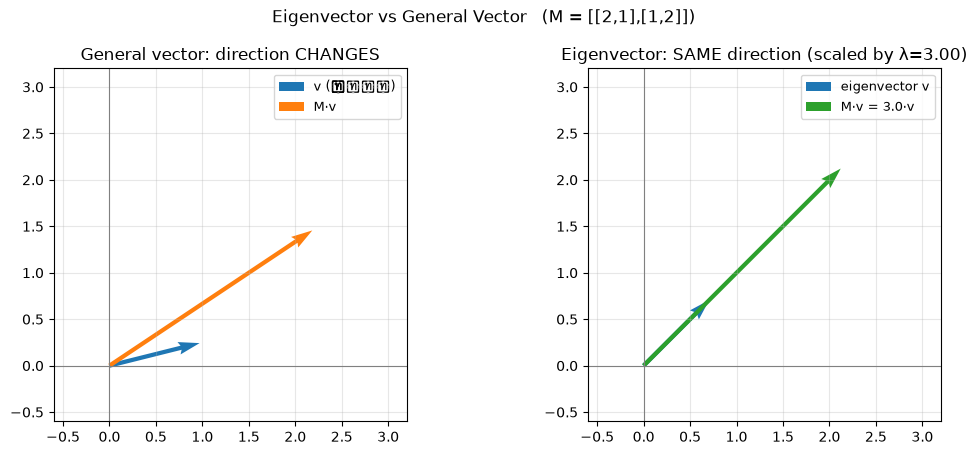

In [46]:
# ===== เปรียบเทียบ: eigenvector ไม่หมุน แต่ vector ทั่วไปหมุน =====
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# ใช้เมทริกซ์ 2x2 เพื่อวาดบนระนาบให้เห็นภาพชัด
M2 = np.array([[2.0, 1.0], [1.0, 2.0]])
w2, V2 = np.linalg.eig(M2)

# (ซ้าย) vector ทั่วไป -> ทิศทางเปลี่ยน
ax = axes[0]
v_gen = np.array([1.0, 0.25]); v_gen /= np.linalg.norm(v_gen)
Mv = M2 @ v_gen
ax.quiver(0, 0, *v_gen, angles="xy", scale_units="xy", scale=1, color="tab:blue",  width=0.012, label="v (ทั่วไป)")
ax.quiver(0, 0, *Mv,    angles="xy", scale_units="xy", scale=1, color="tab:orange", width=0.012, label="M·v")
ax.set_title("General vector: direction CHANGES")

# (ขวา) eigenvector -> ทิศทางเดิม แค่ยาวขึ้น
ax2 = axes[1]
v_eig = V2[:, 0]
Mv_eig = M2 @ v_eig
ax2.quiver(0, 0, *v_eig,  angles="xy", scale_units="xy", scale=1, color="tab:blue",  width=0.012, label="eigenvector v")
ax2.quiver(0, 0, *Mv_eig, angles="xy", scale_units="xy", scale=1, color="tab:green", width=0.012, label=f"M·v = {w2[0]:.1f}·v")
ax2.set_title(f"Eigenvector: SAME direction (scaled by λ={w2[0]:.2f})")

for axx in (ax, ax2):
    axx.set_xlim(-0.6, 3.2); axx.set_ylim(-0.6, 3.2)
    axx.axhline(0, color="gray", lw=0.8); axx.axvline(0, color="gray", lw=0.8)
    axx.grid(alpha=0.3); axx.legend(fontsize=9); axx.set_aspect("equal")

plt.suptitle("Eigenvector vs General Vector   (M = [[2,1],[1,2]])")
plt.tight_layout()
plt.show()

---
# Section 4 - Calculus

Calculus ตอบคำถามเดียวที่สำคัญที่สุดในการเทรนโมเดล:
> **"ถ้าขยับพารามิเตอร์ไปนิดหนึ่ง ค่า loss จะเปลี่ยนไปเท่าไหร่ และควรขยับไปทางไหน?"**

ในหัวข้อนี้ใช้ **SymPy** หาอนุพันธ์แบบสัญลักษณ์ (ได้สูตรออกมาจริง ๆ) แล้วนำไปพล็อตเทียบกับฟังก์ชันต้นฉบับ

## 4.1a Derivative (อนุพันธ์)

อนุพันธ์คือ **อัตราการเปลี่ยนแปลงชั่วขณะ** = ความชันของเส้นสัมผัส ณ จุดนั้น

$$
f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

**กฎที่ใช้บ่อย**

$$
\frac{d}{dx}(c) = 0 \qquad
\frac{d}{dx}(x^{n}) = n x^{n-1} \qquad
\frac{d}{dx}(e^{x}) = e^{x} \qquad
\frac{d}{dx}\big(af + bg\big) = af' + bg'
$$

ตัวอย่างที่ใช้: $f(x) = 3x^{3} - 5x^{2} + 2x + 7$

In [47]:
x = sp.symbols("x")
f = 3*x**3 - 5*x**2 + 2*x + 7

f_prime  = sp.diff(f, x)        # อนุพันธ์อันดับ 1
f_second = sp.diff(f, x, 2)     # อนุพันธ์อันดับ 2

print("ฟังก์ชันและอนุพันธ์ (คำนวณด้วย SymPy)")
print("=" * 50)
display(sp.Eq(sp.Function("f")(x), f))
display(sp.Eq(sp.Symbol("f'(x)"), f_prime))
display(sp.Eq(sp.Symbol("f''(x)"), f_second))

# หาจุดวิกฤต (critical points) ที่ f'(x) = 0
critical = sp.solve(f_prime, x)
print("\nจุดวิกฤต (f'(x) = 0):")
for c in critical:
    c_val = float(c)
    kind = "จุดต่ำสุดเฉพาะที่ (local min)" if f_second.subs(x, c) > 0 else "จุดสูงสุดเฉพาะที่ (local max)"
    print(f"  x = {c_val: .4f}  ->  f(x) = {float(f.subs(x, c)): .4f}   [{kind}]")

ฟังก์ชันและอนุพันธ์ (คำนวณด้วย SymPy)


Eq(f(x), 3*x**3 - 5*x**2 + 2*x + 7)

Eq(f'(x), 9*x**2 - 10*x + 2)

Eq(f''(x), 2*(9*x - 5))


จุดวิกฤต (f'(x) = 0):
  x =  0.2616  ->  f(x) =  7.2347   [จุดสูงสุดเฉพาะที่ (local max)]
  x =  0.8495  ->  f(x) =  6.9299   [จุดต่ำสุดเฉพาะที่ (local min)]


In [48]:
# ===== ตรวจสอบเชิงตัวเลข: เทียบ derivative จากสูตร กับ นิยาม limit =====
f_num  = sp.lambdify(x, f, "numpy")          # แปลงสมการ SymPy -> ฟังก์ชัน numpy
fp_num = sp.lambdify(x, f_prime, "numpy")

x0, h = 2.0, 1e-6
numeric  = (f_num(x0 + h) - f_num(x0)) / h   # ตามนิยาม (finite difference)
symbolic = fp_num(x0)

print(f"ที่จุด x = {x0}")
print(f"  f({x0})            = {f_num(x0):.4f}")
print(f"  f'({x0}) จากสูตร    = {symbolic:.6f}")
print(f"  f'({x0}) จากนิยาม   = {numeric:.6f}   (h = {h})")
print(f"  ต่างกัน             = {abs(symbolic - numeric):.2e}  -> ตรงกัน")

ที่จุด x = 2.0
  f(2.0)            = 15.0000
  f'(2.0) จากสูตร    = 18.000000
  f'(2.0) จากนิยาม   = 18.000013   (h = 1e-06)
  ต่างกัน             = 1.30e-05  -> ตรงกัน


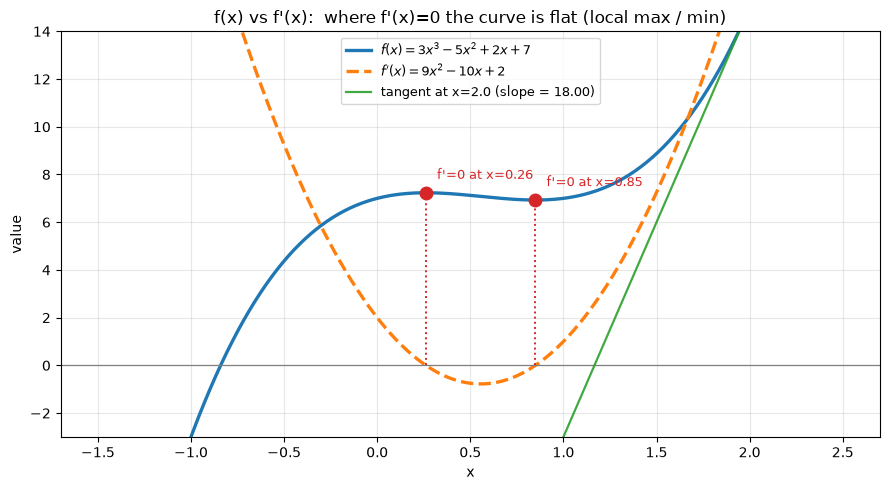

In [49]:
# ===== พล็อตเทียบ f(x) กับ f'(x) =====
xs = np.linspace(-1.5, 2.5, 400)
ys, dys = f_num(xs), fp_num(xs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, ys,  color="tab:blue",   lw=2.4, label=r"$f(x) = 3x^3 - 5x^2 + 2x + 7$")
ax.plot(xs, dys, color="tab:orange", lw=2.4, ls="--", label=r"$f'(x) = 9x^2 - 10x + 2$")
ax.axhline(0, color="gray", lw=0.9)

# ทำเครื่องหมายจุดวิกฤต: f'(x)=0 ตรงกับจุดยอด/ท้องของ f(x) พอดี
for c in critical:
    cv = float(c)
    ax.plot(cv, f_num(cv), "o", color="tab:red", ms=9, zorder=5)
    ax.vlines(cv, 0, f_num(cv), color="tab:red", ls=":", lw=1.4)
    ax.annotate(f"f'={0:.0f} at x={cv:.2f}", (cv, f_num(cv)),
                textcoords="offset points", xytext=(8, 10), fontsize=9, color="tab:red")

# เส้นสัมผัสที่ x = 2 เพื่อยืนยันความหมายของ "ความชัน"
xt = 2.0
tangent = f_num(xt) + fp_num(xt) * (xs - xt)
ax.plot(xs, tangent, color="tab:green", lw=1.6, alpha=0.9,
        label=f"tangent at x={xt} (slope = {fp_num(xt):.2f})")
ax.plot(xt, f_num(xt), "o", color="tab:green", ms=8)

ax.set_xlabel("x"); ax.set_ylabel("value")
ax.set_title("f(x) vs f'(x):  where f'(x)=0 the curve is flat (local max / min)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(-3, 14)
plt.tight_layout()
plt.show()

## 4.2b Partial Derivative (อนุพันธ์ย่อย)

เมื่อฟังก์ชันมี **หลายตัวแปร** เราหาอนุพันธ์ *ทีละตัวแปร* โดย **ตรึงตัวแปรอื่นให้เป็นค่าคงที่**

$$
\frac{\partial f}{\partial x}, \qquad \frac{\partial f}{\partial y}
$$

### ตั้งต้นสำหรับ Gradient Descent

เราจะใช้แบบจำลอง **linear regression** และ loss แบบ **MSE** ซึ่งเป็นตัวอย่างมาตรฐาน

$$
\hat{y}_i = w x_i + b
\qquad\qquad
L(w,b) = \mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}\big(y_i - (w x_i + b)\big)^{2}
$$

หา partial derivative ของ loss เทียบกับพารามิเตอร์แต่ละตัว (นี่คือสิ่งที่ optimizer ต้องใช้):

$$
\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^{n} x_i\big(y_i - (w x_i + b)\big)
\qquad
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}\big(y_i - (w x_i + b)\big)
$$

In [50]:
# ===== (ก) partial derivative ของฟังก์ชัน 2 ตัวแปรทั่วไป =====
xs_, ys_ = sp.symbols("x y")
g = xs_**2 + 3*ys_**2 + 2*xs_*ys_

dg_dx = sp.diff(g, xs_)
dg_dy = sp.diff(g, ys_)

print("ตัวอย่างฟังก์ชัน 2 ตัวแปร")
display(sp.Eq(sp.Symbol("g(x,y)"), g))
display(sp.Eq(sp.Symbol(r"\partial g/\partial x"), dg_dx))
display(sp.Eq(sp.Symbol(r"\partial g/\partial y"), dg_dy))

pt = {xs_: 2, ys_: 1}
print(f"\nที่จุด (x,y) = (2,1):  ∂g/∂x = {dg_dx.subs(pt)},  ∂g/∂y = {dg_dy.subs(pt)}")

ตัวอย่างฟังก์ชัน 2 ตัวแปร


Eq(g(x,y), x**2 + 2*x*y + 3*y**2)

Eq(\partial g/\partial x, 2*x + 2*y)

Eq(\partial g/\partial y, 2*x + 6*y)


ที่จุด (x,y) = (2,1):  ∂g/∂x = 6,  ∂g/∂y = 10


In [51]:
# ===== (ข) partial derivative ของ MSE loss -> ใช้ต่อใน Gradient Descent =====
w, b, xi, yi = sp.symbols("w b x_i y_i")

y_pred = w*xi + b                       # โมเดลเชิงเส้น
err_sq = (yi - y_pred)**2               # squared error ของ 1 ตัวอย่าง

dL_dw = sp.simplify(sp.diff(err_sq, w))
dL_db = sp.simplify(sp.diff(err_sq, b))

print("Squared error ของ 1 ตัวอย่าง:")
display(sp.Eq(sp.Symbol("e_i"), err_sq))
print("\nอนุพันธ์ย่อยเทียบกับพารามิเตอร์:")
display(sp.Eq(sp.Symbol(r"\partial e_i/\partial w"), dL_dw))
display(sp.Eq(sp.Symbol(r"\partial e_i/\partial b"), dL_db))
print("\nเมื่อเฉลี่ยทั้ง n ตัวอย่างจะได้ gradient ของ MSE:")
print("   ∂L/∂w = -(2/n) Σ xᵢ(yᵢ - (w xᵢ + b))")
print("   ∂L/∂b = -(2/n) Σ (yᵢ - (w xᵢ + b))")

Squared error ของ 1 ตัวอย่าง:


Eq(e_i, (-b - w*x_i + y_i)**2)


อนุพันธ์ย่อยเทียบกับพารามิเตอร์:


Eq(\partial e_i/\partial w, 2*x_i*(b + w*x_i - y_i))

Eq(\partial e_i/\partial b, 2*b + 2*w*x_i - 2*y_i)


เมื่อเฉลี่ยทั้ง n ตัวอย่างจะได้ gradient ของ MSE:
   ∂L/∂w = -(2/n) Σ xᵢ(yᵢ - (w xᵢ + b))
   ∂L/∂b = -(2/n) Σ (yᵢ - (w xᵢ + b))


## 4.3c Gradient
**Gradient** คือ vector ที่รวม partial derivative ของทุกตัวแปรเข้าด้วยกัน

$$
\nabla f = \begin{bmatrix}
\dfrac{\partial f}{\partial x} \\[6pt]
\dfrac{\partial f}{\partial y}
\end{bmatrix}
$$

**ความหมาย:**
- $\nabla f$ ชี้ไปทาง **ที่ค่าฟังก์ชันเพิ่มขึ้นเร็วที่สุด** (steepest ascent)
- $-\nabla f$ ชี้ไปทาง **ที่ค่าลดลงเร็วที่สุด** ← ทิศที่ gradient descent เดิน
- ขนาด $\|\nabla f\|$ บอกว่าความชัน ณ จุดนั้นชันแค่ไหน

In [52]:
grad_g = sp.Matrix([dg_dx, dg_dy])
print("Gradient ของ g(x,y) = x² + 3y² + 2xy")
display(sp.Eq(sp.Symbol(r"\nabla g"), grad_g))

pts = [(2, 1), (0, 0), (-1, 2)]
print("\nค่า gradient ณ จุดต่าง ๆ")
print("-" * 56)
for px, py in pts:
    gv = np.array([float(dg_dx.subs({xs_: px, ys_: py})),
                   float(dg_dy.subs({xs_: px, ys_: py}))])
    print(f"  ที่ ({px:>2}, {py:>2}) : ∇g = {gv}   ||∇g|| = {np.linalg.norm(gv):.4f}")
print("-" * 56)
print("ที่ (0,0) gradient เป็นศูนย์ -> เป็นจุดวิกฤต (จุดต่ำสุดของฟังก์ชันนี้)")

Gradient ของ g(x,y) = x² + 3y² + 2xy


False


ค่า gradient ณ จุดต่าง ๆ
--------------------------------------------------------
  ที่ ( 2,  1) : ∇g = [ 6. 10.]   ||∇g|| = 11.6619
  ที่ ( 0,  0) : ∇g = [0. 0.]   ||∇g|| = 0.0000
  ที่ (-1,  2) : ∇g = [ 2. 10.]   ||∇g|| = 10.1980
--------------------------------------------------------
ที่ (0,0) gradient เป็นศูนย์ -> เป็นจุดวิกฤต (จุดต่ำสุดของฟังก์ชันนี้)


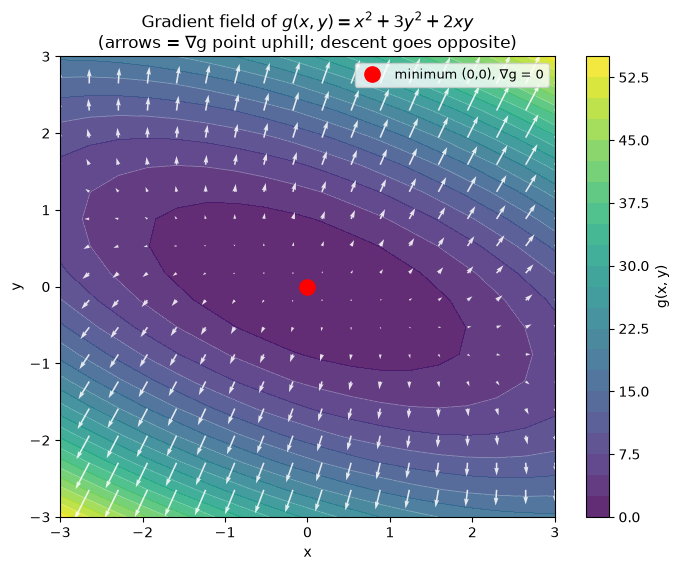

In [53]:
# ===== วาด gradient field: ลูกศรชี้ทางขึ้นชันสุด =====
gx, gy = np.meshgrid(np.linspace(-3, 3, 18), np.linspace(-3, 3, 18))
G  = gx**2 + 3*gy**2 + 2*gx*gy
U  = 2*gx + 2*gy          # ∂g/∂x
V  = 6*gy + 2*gx          # ∂g/∂y

fig, ax = plt.subplots(figsize=(7, 5.8))
cs = ax.contourf(gx, gy, G, levels=22, cmap="viridis", alpha=0.85)
ax.contour(gx, gy, G, levels=12, colors="white", linewidths=0.5, alpha=0.5)
ax.quiver(gx, gy, U, V, color="white", alpha=0.85, width=0.0032)
ax.plot(0, 0, "o", color="red", ms=11, label="minimum (0,0), ∇g = 0")

plt.colorbar(cs, ax=ax, label="g(x, y)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"Gradient field of $g(x,y)=x^2+3y^2+2xy$" + "\n(arrows = ∇g point uphill; descent goes opposite)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 4.4d Gradient Descent

### แนวคิด

Gradient Descent คืออัลกอริทึมหา *ค่าต่ำสุด* ของ loss function โดยทำซ้ำ 3 ขั้นตอน:

1. คำนวณ **loss** ปัจจุบัน
2. คำนวณ **gradient** (ความชัน) ของ loss เทียบกับพารามิเตอร์
3. ขยับพารามิเตอร์ **สวนทาง gradient** เป็นระยะตาม learning rate

$$
\theta \;\leftarrow\; \theta - \alpha \nabla L(\theta)
$$

โดยที่ $\alpha$ = **learning rate** (ขนาดก้าว)

| $\alpha$ | ผลที่เกิด |
|----------|-----------|
| เล็กเกินไป | ลู่เข้าช้ามาก เสียเวลาเทรน |
| พอเหมาะ | ลู่เข้าสู่จุดต่ำสุดอย่างราบรื่น |
| ใหญ่เกินไป | ก้าวข้ามจุดต่ำสุด แกว่งหรือ **ลู่ออก (diverge)** |

### สมการที่ใช้ในตัวอย่างนี้

**โมเดล:** $\hat{y} = wx + b$ **· Loss:** $L = \mathrm{MSE} = \dfrac{1}{n}\sum(y_i-\hat{y}_i)^2$

**กฎการอัปเดต:**

$$
w \leftarrow w - \alpha\frac{\partial L}{\partial w}
\qquad\qquad
b \leftarrow b - \alpha\frac{\partial L}{\partial b}
$$

**การทดลอง:** กำหนด learning rate แล้วคำนวณ **5 รอบ** ตามโจทย์ เพื่อดูการเปลี่ยนแปลงของค่าต่าง ๆ

In [54]:
# ===== เตรียมข้อมูลสุ่มสำหรับ linear regression =====
n_samples = 30
TRUE_W, TRUE_B = 3.0, 2.0                       # ค่าจริงที่เราอยากให้โมเดลเรียนได้

X_data = rng.uniform(-2, 2, n_samples)
noise  = rng.normal(0, 0.7, n_samples)          # สัญญาณรบกวน
y_data = TRUE_W * X_data + TRUE_B + noise

print(f"จำนวนข้อมูล n = {n_samples}")
print(f"ความจริง (ที่โมเดลควรเรียนได้) : w = {TRUE_W}, b = {TRUE_B}")
print(f"\nตัวอย่าง 5 แถวแรก")
display(pd.DataFrame({"x": X_data[:5], "y": y_data[:5]}))

จำนวนข้อมูล n = 30
ความจริง (ที่โมเดลควรเรียนได้) : w = 3.0, b = 2.0

ตัวอย่าง 5 แถวแรก


,x,y
0,1.3105,6.5416
1,0.5267,3.7365
2,1.0324,5.5723
3,-0.5819,0.3016
4,1.8828,7.8508


In [55]:
# ===== นิยามฟังก์ชัน loss และ gradient (ตามสมการที่หาไว้ในหัวข้อ 5.2) =====
def predict(X, w, b):
    """ŷ = wx + b"""
    return w * X + b

def mse_loss(X, y, w, b):
    """L = (1/n) Σ (y - ŷ)²"""
    return float(np.mean((y - predict(X, w, b)) ** 2))

def gradients(X, y, w, b):
    """∂L/∂w = -(2/n) Σ x(y - ŷ)   ,   ∂L/∂b = -(2/n) Σ (y - ŷ)"""
    n = len(X)
    error = y - predict(X, w, b)
    dw = -(2 / n) * np.sum(X * error)
    db = -(2 / n) * np.sum(error)
    return float(dw), float(db)

# --- กำหนดค่าเริ่มต้นและ learning rate ---
w_cur, b_cur  = 0.0, 0.0        # เริ่มจากศูนย์
LEARNING_RATE = 0.1             # <<< learning rate ที่กำหนด
N_ITER        = 5               # <<< คำนวณ 5 รอบตามโจทย์

print(f"ค่าเริ่มต้น      : w = {w_cur}, b = {b_cur}")
print(f"learning rate α : {LEARNING_RATE}")
print(f"จำนวนรอบ        : {N_ITER}")
print(f"loss เริ่มต้น    : {mse_loss(X_data, y_data, w_cur, b_cur):.6f}")

ค่าเริ่มต้น      : w = 0.0, b = 0.0
learning rate α : 0.1
จำนวนรอบ        : 5
loss เริ่มต้น    : 16.940134


In [56]:
# ===== รัน Gradient Descent 5 รอบ พร้อมบันทึกค่าทุกรอบ =====
history = []
w_cur, b_cur = 0.0, 0.0

for step in range(1, N_ITER + 1):
    loss   = mse_loss(X_data, y_data, w_cur, b_cur)
    dw, db = gradients(X_data, y_data, w_cur, b_cur)

    history.append({
        "iteration": step - 1, "w": w_cur, "b": b_cur,
        "MSE_loss": loss, "dL/dw": dw, "dL/db": db,
        "w_new": w_cur - LEARNING_RATE * dw,
        "b_new": b_cur - LEARNING_RATE * db,
    })

    # --- อัปเดตพารามิเตอร์: θ ← θ - α ∇L ---
    w_cur -= LEARNING_RATE * dw
    b_cur -= LEARNING_RATE * db

    print(f"รอบที่ {step}: loss = {loss:8.5f} | ∂L/∂w = {dw:8.5f} | ∂L/∂b = {db:8.5f} "
          f"|| w: {history[-1]['w']:.5f} -> {w_cur:.5f} , b: {history[-1]['b']:.5f} -> {b_cur:.5f}")

final_loss = mse_loss(X_data, y_data, w_cur, b_cur)
print("\n" + "=" * 74)
print(f"หลังครบ {N_ITER} รอบ : w = {w_cur:.5f}, b = {b_cur:.5f}, loss = {final_loss:.5f}")
print(f"ค่าจริง            : w = {TRUE_W}, b = {TRUE_B}")
print(f"loss ลดลง          : {history[0]['MSE_loss']:.5f} -> {final_loss:.5f} "
      f"({(1 - final_loss / history[0]['MSE_loss']) * 100:.2f}% )")

รอบที่ 1: loss = 16.94013 | ∂L/∂w = -7.81160 | ∂L/∂b = -4.70439 || w: 0.00000 -> 0.78116 , b: 0.00000 -> 0.47044
รอบที่ 2: loss =  9.66429 | ∂L/∂w = -5.83273 | ∂L/∂b = -3.57149 || w: 0.78116 -> 1.36443 , b: 0.47044 -> 0.82759
รอบที่ 3: loss =  5.57116 | ∂L/∂w = -4.35371 | ∂L/∂b = -2.71381 || w: 1.36443 -> 1.79980 , b: 0.82759 -> 1.09897
รอบที่ 4: loss =  3.26796 | ∂L/∂w = -3.24855 | ∂L/∂b = -2.06402 || w: 1.79980 -> 2.12466 , b: 1.09897 -> 1.30537
รอบที่ 5: loss =  1.97157 | ∂L/∂w = -2.42296 | ∂L/∂b = -1.57136 || w: 2.12466 -> 2.36695 , b: 1.30537 -> 1.46251

หลังครบ 5 รอบ : w = 2.36695, b = 1.46251, loss = 1.24165
ค่าจริง            : w = 3.0, b = 2.0
loss ลดลง          : 16.94013 -> 1.24165 (92.67% )


In [57]:
# ===== ตารางสรุปการเปลี่ยนแปลงในแต่ละรอบ =====
hist_df = pd.DataFrame(history)
display(hist_df[["iteration", "w", "b", "MSE_loss", "dL/dw", "dL/db", "w_new", "b_new"]])

,iteration,w,b,MSE_loss,dL/dw,dL/db,w_new,b_new
0,0,0.0000,0.0000,16.9401,-7.8116,-4.7044,0.7812,0.4704
1,1,0.7812,0.4704,9.6643,-5.8327,-3.5715,1.3644,0.8276
2,2,1.3644,0.8276,5.5712,-4.3537,-2.7138,1.7998,1.0990
3,3,1.7998,1.0990,3.2680,-3.2485,-2.0640,2.1247,1.3054
4,4,2.1247,1.3054,1.9716,-2.4230,-1.5714,2.3670,1.4625


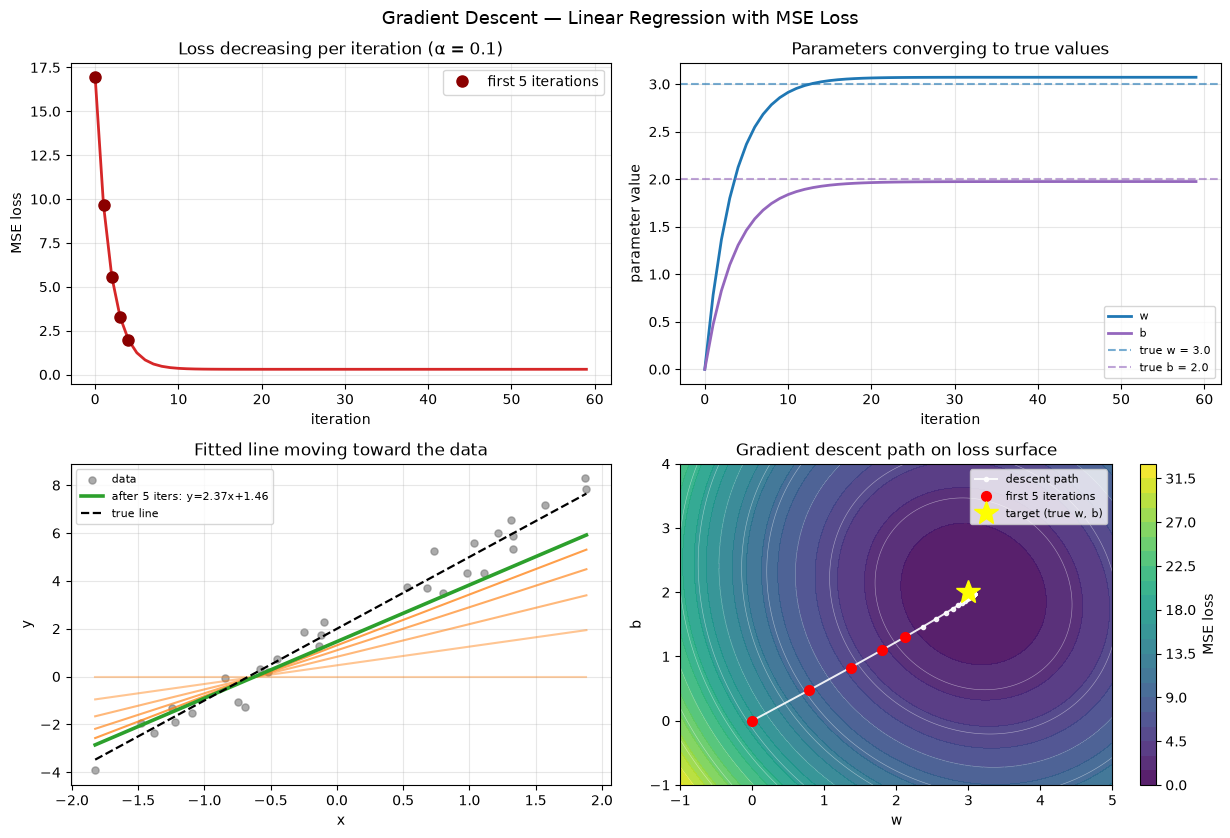

In [58]:
# ===== พล็อตกราฟค่าที่เปลี่ยนไปในแต่ละรอบ =====
# เก็บค่าเพิ่มอีกหลายรอบเพื่อให้เห็นแนวโน้มการลู่เข้า (นอกเหนือจาก 5 รอบที่โจทย์กำหนด)
w_t, b_t = 0.0, 0.0
long_hist = []
for step in range(60):
    long_hist.append((step, w_t, b_t, mse_loss(X_data, y_data, w_t, b_t)))
    dw, db = gradients(X_data, y_data, w_t, b_t)
    w_t -= LEARNING_RATE * dw
    b_t -= LEARNING_RATE * db
long_df = pd.DataFrame(long_hist, columns=["iter", "w", "b", "loss"])

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))

# (1) Loss ต่อรอบ
ax = axes[0, 0]
ax.plot(long_df["iter"], long_df["loss"], color="tab:red", lw=2)
ax.plot(hist_df["iteration"], hist_df["MSE_loss"], "o", color="darkred", ms=8, label="first 5 iterations")
ax.set_xlabel("iteration"); ax.set_ylabel("MSE loss")
ax.set_title(f"Loss decreasing per iteration (α = {LEARNING_RATE})")
ax.grid(alpha=0.3); ax.legend()

# (2) w และ b ต่อรอบ
ax = axes[0, 1]
ax.plot(long_df["iter"], long_df["w"], color="tab:blue",   lw=2, label="w")
ax.plot(long_df["iter"], long_df["b"], color="tab:purple", lw=2, label="b")
ax.axhline(TRUE_W, color="tab:blue",   ls="--", alpha=0.6, label=f"true w = {TRUE_W}")
ax.axhline(TRUE_B, color="tab:purple", ls="--", alpha=0.6, label=f"true b = {TRUE_B}")
ax.set_xlabel("iteration"); ax.set_ylabel("parameter value")
ax.set_title("Parameters converging to true values")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# (3) เส้น fit ที่ค่อย ๆ ขยับเข้าหาข้อมูล
ax = axes[1, 0]
ax.scatter(X_data, y_data, s=26, alpha=0.65, color="tab:gray", label="data")
xs_line = np.linspace(X_data.min(), X_data.max(), 50)
for i, row in hist_df.iterrows():
    ax.plot(xs_line, row["w"] * xs_line + row["b"], alpha=0.35 + 0.1 * i,
            color="tab:orange", lw=1.5)
ax.plot(xs_line, w_cur * xs_line + b_cur, color="tab:green", lw=2.6,
        label=f"after {N_ITER} iters: y={w_cur:.2f}x+{b_cur:.2f}")
ax.plot(xs_line, TRUE_W * xs_line + TRUE_B, color="black", ls="--", lw=1.6, label="true line")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Fitted line moving toward the data")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# (4) เส้นทางเดินบน loss surface
ax = axes[1, 1]
wg, bg = np.meshgrid(np.linspace(-1, 5, 120), np.linspace(-1, 4, 120))
loss_grid = np.array([[mse_loss(X_data, y_data, wv, bv) for wv in wg[0]] for bv in bg[:, 0]])
cs = ax.contourf(wg, bg, loss_grid, levels=28, cmap="viridis", alpha=0.9)
ax.contour(wg, bg, loss_grid, levels=14, colors="white", linewidths=0.4, alpha=0.5)
ax.plot(long_df["w"], long_df["b"], "-o", color="white", ms=3, lw=1.4, alpha=0.9, label="descent path")
ax.plot(hist_df["w"], hist_df["b"], "o", color="red", ms=7, label="first 5 iterations")
ax.plot(TRUE_W, TRUE_B, "*", color="yellow", ms=18, label="target (true w, b)")
plt.colorbar(cs, ax=ax, label="MSE loss")
ax.set_xlabel("w"); ax.set_ylabel("b")
ax.set_title("Gradient descent path on loss surface")
ax.legend(fontsize=8)

plt.suptitle("Gradient Descent — Linear Regression with MSE Loss", fontsize=13)
plt.tight_layout()
plt.show()

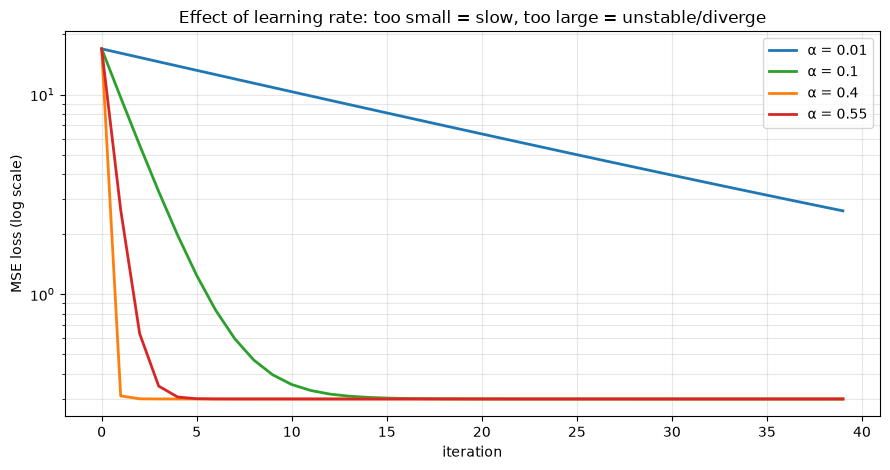

สรุป: α เล็ก -> ลู่เข้าช้า | α พอเหมาะ -> ลู่เข้าเร็วและนิ่ง | α ใหญ่เกิน -> แกว่ง/ลู่ออก


In [59]:
# ===== ทดลองเปรียบเทียบผลของ learning rate ต่าง ๆ =====
fig, ax = plt.subplots(figsize=(9, 4.8))

for lr, color in [(0.01, "tab:blue"), (0.1, "tab:green"), (0.4, "tab:orange"), (0.55, "tab:red")]:
    ww, bb, losses = 0.0, 0.0, []
    for _ in range(40):
        losses.append(mse_loss(X_data, y_data, ww, bb))
        dw, db = gradients(X_data, y_data, ww, bb)
        ww -= lr * dw
        bb -= lr * db
        if not np.isfinite(ww) or abs(ww) > 1e6:      # ลู่ออก
            break
    ax.plot(losses, color=color, lw=2, label=f"α = {lr}")

ax.set_yscale("log")
ax.set_xlabel("iteration"); ax.set_ylabel("MSE loss (log scale)")
ax.set_title("Effect of learning rate: too small = slow, too large = unstable/diverge")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout()
plt.show()

print("สรุป: α เล็ก -> ลู่เข้าช้า | α พอเหมาะ -> ลู่เข้าเร็วและนิ่ง | α ใหญ่เกิน -> แกว่ง/ลู่ออก")

---
# Section 5 - Descriptive Statistics

สถิติเชิงพรรณนา ใช้ **สรุปลักษณะของข้อมูล** ให้เหลือตัวเลขไม่กี่ตัวที่เล่าเรื่องได้
เป็นด่านแรกของการทำ EDA (Exploratory Data Analysis) ก่อนสร้างโมเดล

**ข้อมูลที่ใช้:** สุ่มข้อมูลจำลอง 2 ชุด
- `height` — ส่วนสูง (นิยมแจกแจงแบบปกติ / normal distribution)
- `weight` — น้ำหนัก ซึ่งสัมพันธ์กับส่วนสูง (เพื่อใช้ดู covariance & correlation)

In [60]:
# ===== สุ่มชุดข้อมูลสำหรับวิเคราะห์สถิติ =====
N = 200
height = rng.normal(loc=168, scale=8, size=N)              # ค่าเฉลี่ย 168 cm, SD 8
weight = 0.75 * height - 62 + rng.normal(0, 5, size=N)     # สัมพันธ์กับส่วนสูง + noise

df = pd.DataFrame({"height_cm": height, "weight_kg": weight})

print(f"จำนวนข้อมูล (n) = {N}")
display(df.head())
print("\nสรุปด้วย pandas .describe()")
display(df.describe())

จำนวนข้อมูล (n) = 200


,height_cm,weight_kg
0,164.5820,57.6212
1,169.2683,59.3892
2,173.0047,73.7093
3,165.5252,63.4577
4,171.6542,69.1414



สรุปด้วย pandas .describe()


,height_cm,weight_kg
count,200.0000,200.0000
mean,167.6157,63.7205
std,7.8263,7.7565
min,150.8217,44.3736
25%,162.1905,58.1990
50%,166.9015,63.3106
75%,171.5007,68.4204
max,191.3109,87.0034


## 5.1a – 5.8h ค่าสถิติพื้นฐาน

$$
\text{Mean:}\quad \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
\qquad\qquad
\text{Median:}\quad \tilde{x} = \text{ค่ากลางเมื่อเรียงข้อมูลแล้ว}
$$

$$
\text{Range} = \max(x) - \min(x)
\qquad\qquad
\text{IQR} = Q_3 - Q_1
$$

$$
\text{Variance:}\quad s^{2} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^{2}
\qquad\qquad
\text{Standard Deviation:}\quad s = \sqrt{s^{2}}
$$

> **หมายเหตุ** ตัวหาร $n-1$ คือ *sample variance* (Bessel's correction) ซึ่งเป็นค่าที่ใช้กับข้อมูลตัวอย่าง
> ใน NumPy ต้องระบุ `ddof=1` ส่วน pandas ใช้ `ddof=1` เป็นค่าเริ่มต้นอยู่แล้ว
>
> **Mean vs Median:** mean ไวต่อค่าผิดปกติ (outlier) ส่วน median ทนทานกว่า

In [61]:
col = df["height_cm"].values

mean_v   = np.mean(col)
median_v = np.median(col)
min_v    = np.min(col)
max_v    = np.max(col)
range_v  = max_v - min_v
q1, q3   = np.percentile(col, [25, 75])
iqr_v    = q3 - q1
var_v    = np.var(col, ddof=1)        # ddof=1 -> sample variance
std_v    = np.std(col, ddof=1)

stats_table = pd.DataFrame({
    "สถิติ (statistic)": ["Mean (ค่าเฉลี่ย)", "Median (มัธยฐาน)", "Minimum", "Maximum",
                          "Range", "Q1 (25%)", "Q3 (75%)", "IQR", "Variance (s²)", "Std. Deviation (s)"],
    "ค่า (value)": np.round([mean_v, median_v, min_v, max_v, range_v,
                             q1, q3, iqr_v, var_v, std_v], 4),
})
print("สถิติเชิงพรรณนาของ height_cm")
display(stats_table)

# ตรวจสอบด้วยการคำนวณตามนิยาม
manual_var = sum((v - mean_v) ** 2 for v in col) / (len(col) - 1)
print(f"\nตรวจสอบ variance ตามนิยาม = {manual_var:.6f}  |  numpy = {var_v:.6f}  ->  ตรงกัน: {np.isclose(manual_var, var_v)}")
print(f"ตรวจสอบ  s = sqrt(s²)      = {np.sqrt(var_v):.6f}  |  numpy = {std_v:.6f}")

สถิติเชิงพรรณนาของ height_cm


,สถิติ (statistic),ค่า (value)
0,Mean (ค่าเฉลี่ย),167.6157
1,Median (มัธยฐาน),166.9015
2,Minimum,150.8217
3,Maximum,191.3109
4,Range,40.4892
5,Q1 (25%),162.1905
6,Q3 (75%),171.5007
7,IQR,9.3103
8,Variance (s²),61.2503
9,Std. Deviation (s),7.8263



ตรวจสอบ variance ตามนิยาม = 61.250302  |  numpy = 61.250302  ->  ตรงกัน: True
ตรวจสอบ  s = sqrt(s²)      = 7.826257  |  numpy = 7.826257


## 5.9i Histogram

**Histogram** แสดง *การแจกแจงความถี่* ของข้อมูล — ช่วยดูรูปร่าง (shape), ความเบ้ (skewness) และค่ากลาง

ในกราฟจะทำเครื่องหมาย mean และ median ไว้เทียบกัน และแรเงาช่วง $\bar{x} \pm s$
ซึ่งครอบคลุมข้อมูลราว **68%** เมื่อข้อมูลมีการแจกแจงแบบปกติ

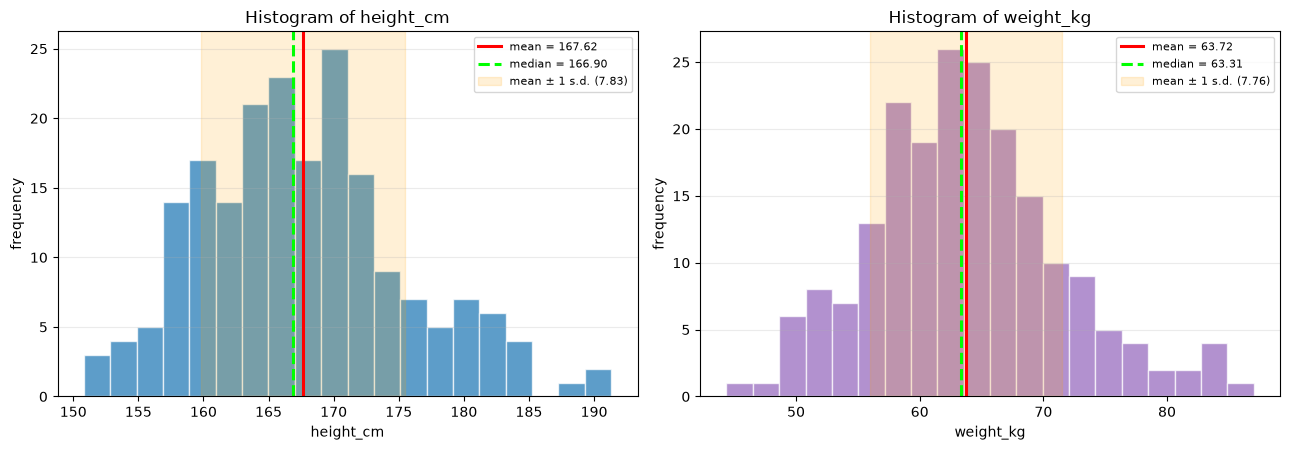

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, cname, color in zip(axes, ["height_cm", "weight_kg"], ["tab:blue", "tab:purple"]):
    data = df[cname].values
    m, md_, s = np.mean(data), np.median(data), np.std(data, ddof=1)

    ax.hist(data, bins=20, color=color, alpha=0.72, edgecolor="white")
    ax.axvline(m,  color="red",   lw=2.2, label=f"mean = {m:.2f}")
    ax.axvline(md_, color="lime", lw=2.2, ls="--", label=f"median = {md_:.2f}")
    ax.axvspan(m - s, m + s, color="orange", alpha=0.16, label=f"mean ± 1 s.d. ({s:.2f})")

    ax.set_xlabel(cname); ax.set_ylabel("frequency")
    ax.set_title(f"Histogram of {cname}")
    ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

## 5.10j Box Plot

**Box Plot** สรุปข้อมูลด้วย *five-number summary*: $\min$, $Q_1$, median, $Q_3$, $\max$

- **กล่อง (box)** = ช่วง $Q_1$ ถึง $Q_3$ (คือ IQR — ครอบคลุมข้อมูลตรงกลาง 50%)
- **เส้นในกล่อง** = median
- **หนวด (whiskers)** = ขยายไปไม่เกิน $1.5 \times IQR$ จากขอบกล่อง
- **จุดนอกหนวด** = จุดที่ *น่าสงสัยว่าเป็น outlier*

$$
\text{ขอบเขต outlier}: \quad [\,Q_1 - 1.5\,IQR,\;\; Q_3 + 1.5\,IQR\,]
$$

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

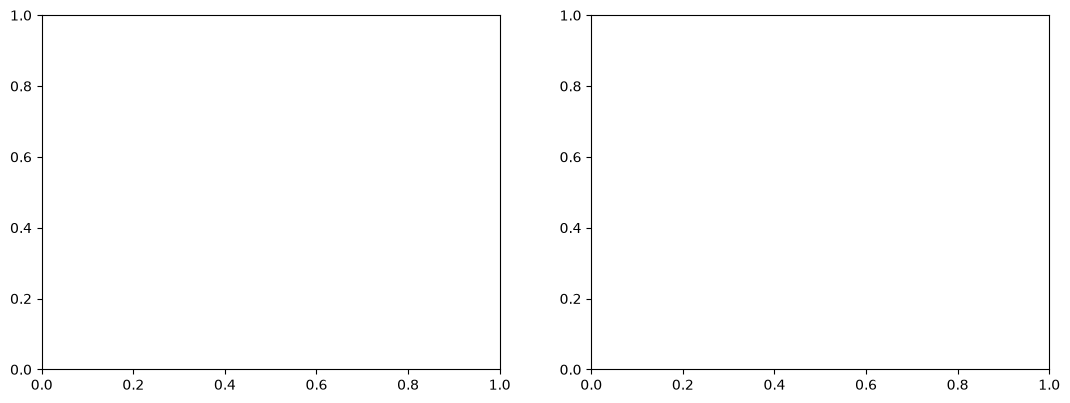

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (ซ้าย) box plot ปกติของทั้ง 2 ตัวแปร
bp = axes[0].boxplot([df["height_cm"], df["weight_kg"]],
                     labels=["height_cm", "weight_kg"], patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
for patch, c in zip(bp["boxes"], ["tab:blue", "tab:purple"]):
    patch.set_facecolor(c); patch.set_alpha(0.55)
axes[0].set_title("Box Plot of both variables")
axes[0].grid(alpha=0.25, axis="y")

# (ขวา) เพิ่ม outlier เข้าไปเพื่อให้เห็นการทำงานของ IQR fences
data_out = np.append(df["height_cm"].values, [125, 132, 205, 212])
q1o, q3o = np.percentile(data_out, [25, 75])
iqro = q3o - q1o
low_f, up_f = q1o - 1.5 * iqro, q3o + 1.5 * iqro
outliers = data_out[(data_out < low_f) | (data_out > up_f)]

axes[1].boxplot(data_out, vert=False, patch_artist=True,
                boxprops=dict(facecolor="tab:orange", alpha=0.55),
                medianprops=dict(color="red", linewidth=2))
axes[1].axvline(low_f, color="red", ls="--", lw=1.5, label=f"lower fence = {low_f:.2f}")
axes[1].axvline(up_f,  color="red", ls="--", lw=1.5, label=f"upper fence = {up_f:.2f}")
axes[1].set_title("Box Plot with injected outliers (IQR fences)")
axes[1].set_xlabel("value"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25, axis="x")

plt.tight_layout()
plt.show()

print(f"Q1 = {q1o:.4f} , Q3 = {q3o:.4f} , IQR = {iqro:.4f}")
print(f"ขอบเขตปกติ = [{low_f:.4f} , {up_f:.4f}]")
print(f"ค่าที่ถูกจับว่าเป็น outlier ({len(outliers)} ค่า) = {np.sort(outliers)}")

## 5.11k Covariance and Correlation

### Covariance — บอก *ทิศทาง* ของการเปลี่ยนแปลงร่วมกัน

$$
\mathrm{Cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

ปัญหาคือค่านี้ **ขึ้นกับหน่วยของข้อมูล** จึงเทียบข้ามคู่ตัวแปรไม่ได้

### Correlation (Pearson) — ทำให้เป็นมาตรฐาน ไร้หน่วย

$$
r_{XY} = \frac{\mathrm{Cov}(X,Y)}{s_X \, s_Y}
\qquad r \in [-1, 1]
$$

| $r$ | ความหมาย |
|-----|----------|
| ใกล้ $+1$ | ตัวแปรเพิ่มไปด้วยกัน (สัมพันธ์เชิงบวก) |
| ใกล้ $0$ | ไม่มีความสัมพันธ์ **เชิงเส้น** |
| ใกล้ $-1$ | ตัวหนึ่งเพิ่ม อีกตัวลด |

> ⚠️ **ข้อควรระวัง 2 ข้อ**
> 1. **Correlation ไม่ได้แปลว่าเป็นเหตุเป็นผล (correlation ≠ causation)**
> 2. Pearson จับได้เฉพาะความสัมพันธ์ **เชิงเส้น** — ข้อมูลรูปโค้ง (เช่นพาราโบลา) อาจได้ $r \approx 0$ ทั้งที่สัมพันธ์กันชัดเจน จึงควร **พล็อตดูเสมอ**

In [ ]:
h, wt = df["height_cm"].values, df["weight_kg"].values

# --- คำนวณตามนิยาม ---
cov_manual  = np.sum((h - h.mean()) * (wt - wt.mean())) / (len(h) - 1)
corr_manual = cov_manual / (np.std(h, ddof=1) * np.std(wt, ddof=1))

# --- ใช้ฟังก์ชันสำเร็จรูป ---
cov_matrix  = np.cov(h, wt)          # เมทริกซ์ความแปรปรวนร่วม
corr_matrix = np.corrcoef(h, wt)

print("Covariance matrix (แนวทแยงคือ variance ของแต่ละตัวแปร)")
display(pd.DataFrame(cov_matrix, index=["height", "weight"], columns=["height", "weight"]))

print("Correlation matrix")
display(pd.DataFrame(corr_matrix, index=["height", "weight"], columns=["height", "weight"]))

print("=" * 62)
print(f"Cov(height, weight)  ตามนิยาม = {cov_manual:.6f}  | numpy = {cov_matrix[0,1]:.6f}")
print(f"Corr(height, weight) ตามนิยาม = {corr_manual:.6f}  | numpy = {corr_matrix[0,1]:.6f}")
print(f"\nสรุป: r = {corr_matrix[0,1]:.4f} -> สัมพันธ์เชิงบวกอย่างชัดเจน (คนสูงมักหนักกว่า)")

Covariance matrix (แนวทแยงคือ variance ของแต่ละตัวแปร)


,height,weight
height,61.2503,46.6289
weight,46.6289,60.1627


Correlation matrix


,height,weight
height,1.0000,0.7681
weight,0.7681,1.0000


Cov(height, weight)  ตามนิยาม = 46.628899  | numpy = 46.628899
Corr(height, weight) ตามนิยาม = 0.768134  | numpy = 0.768134

สรุป: r = 0.7681 -> สัมพันธ์เชิงบวกอย่างชัดเจน (คนสูงมักหนักกว่า)


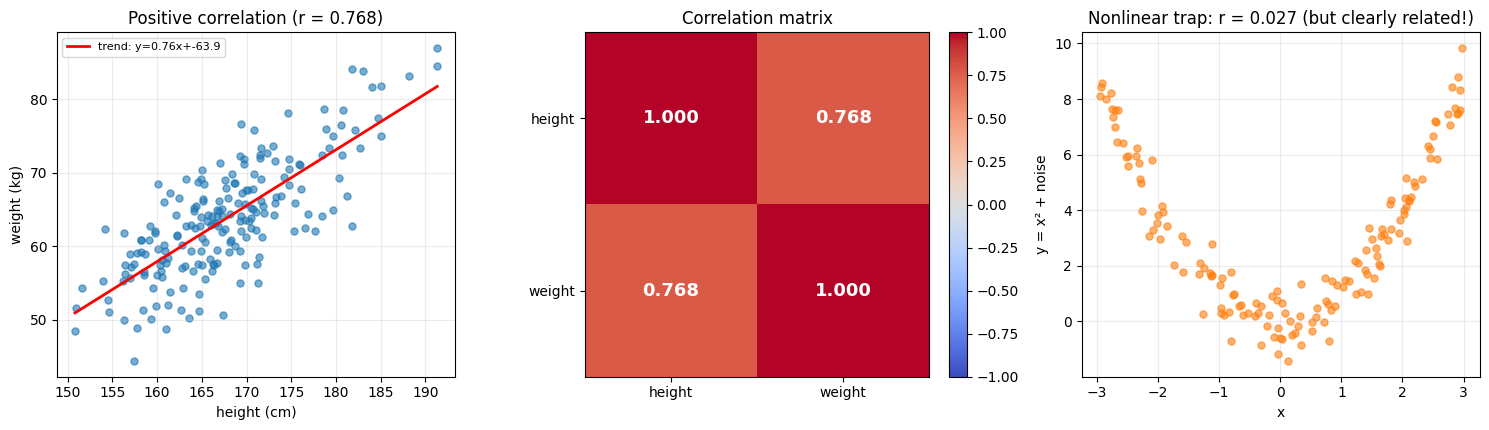

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (1) scatter + เส้นแนวโน้ม
ax = axes[0]
ax.scatter(h, wt, s=26, alpha=0.6, color="tab:blue")
slope, intercept = np.polyfit(h, wt, 1)
xs_fit = np.linspace(h.min(), h.max(), 50)
ax.plot(xs_fit, slope * xs_fit + intercept, color="red", lw=2,
        label=f"trend: y={slope:.2f}x+{intercept:.1f}")
ax.set_xlabel("height (cm)"); ax.set_ylabel("weight (kg)")
ax.set_title(f"Positive correlation (r = {corr_matrix[0,1]:.3f})")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (2) correlation matrix heatmap
ax = axes[1]
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
labels = ["height", "weight"]
ax.set_xticks(range(2), labels); ax.set_yticks(range(2), labels)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{corr_matrix[i,j]:.3f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
ax.set_title("Correlation matrix")
plt.colorbar(im, ax=ax, fraction=0.046)

# (3) กับดัก: ความสัมพันธ์แบบไม่เชิงเส้น -> r ใกล้ 0
ax = axes[2]
x_non = rng.uniform(-3, 3, 150)
y_non = x_non ** 2 + rng.normal(0, 0.6, 150)
r_non = np.corrcoef(x_non, y_non)[0, 1]
ax.scatter(x_non, y_non, s=26, alpha=0.6, color="tab:orange")
ax.set_xlabel("x"); ax.set_ylabel("y = x² + noise")
ax.set_title(f"Nonlinear trap: r = {r_non:.3f} (but clearly related!)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()